# Étape 1 — Nettoyage & Feature Engineering
## Projet MLOps — Home Credit Default Risk

**Fichiers utilisés :**
- `application_train.csv` → données d'entraînement (avec TARGET)

## 0. Imports & Configuration

In [1]:
# numpy and pandas for data manipulation
import numpy as np
import pandas as pd 

# sklearn preprocessing for dealing with categorical variables
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer  

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PolynomialFeatures

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

from xgboost import XGBClassifier

import mlflow
mlflow.set_tracking_uri("sqlite:////home/veron/Documents/OpenClassRoom/p6/mlflow.db")
mlflow.set_experiment("home-credit-scoring")

# File system manangement
import os

# matplotlib and seaborn for plotting
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH   = '/home/veron//Documents/OpenClassRoom/p6/dataset/'
OUTPUT_PATH = '/home/veron//Documents/OpenClassRoom/p6/dataset/'

print('✅ Imports OK')

✅ Imports OK


## 1. Chargement & Exploration

In [2]:
train = pd.read_parquet(DATA_PATH + 'app_train_clean.parquet')

print(f'Train : {train.shape[0]:,} lignes × {train.shape[1]} colonnes')
print(f'\nDistribution TARGET :')
print(train['TARGET'].value_counts(normalize=True).round(3))
print(f'\nDéséquilibre : {train["TARGET"].mean()*100:.1f}% de défauts')

Train : 307,511 lignes × 250 colonnes

Distribution TARGET :
TARGET
0    0.919
1    0.081
Name: proportion, dtype: float64

Déséquilibre : 8.1% de défauts


In [3]:
app_train = pd.read_csv(DATA_PATH + 'application_train.csv')
print('Training data shape: ', app_train.shape)
app_train.head()

Training data shape:  (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


---

On a la variable TARGET, indiquant 0 : le prêt a été remboursé ou 1 : le prêt n’a pas été remboursé. 

---

# Feature Engineering

Le feature engineering recouvre deux processus :

Feature construction : créer de nouvelles variables à partir des données existantes
Feature selection : ne garder que les variables les plus importantes (réduction de dimensionnalité)

Dans ce notebook, on appliquera deux méthodes simples :

Polynomial features (combinaisons polynomiales de variables existantes)
Domain knowledge features (nouvelles variables basées sur la connaissance métier)

### 1.Fonctionnalités polynomiales

Une méthode simple de feature construction consiste à créer des puissances de variables existantes et des termes d'interaction entre elles.
Exemples avec EXT_SOURCE_1 et EXT_SOURCE_2 :

Puissances : EXT_SOURCE_1², EXT_SOURCE_2²
Interactions : EXT_SOURCE_1 × EXT_SOURCE_2, EXT_SOURCE_1² × EXT_SOURCE_2, etc.

L'idée : deux variables faibles individuellement peuvent, combinées, révéler une relation avec la cible qu'aucune n'aurait montrée seule.
On utilise PolynomialFeatures de scikit-learn sur les variables EXT_SOURCE et DAYS_BIRTH, avec un degré de 2.

In [4]:
# Séparer TARGET
poly_target = app_train['TARGET']
cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']
poly_features = app_train[cols].copy()

# Imputer en gardant les noms
imputer = SimpleImputer(strategy='median')
poly_features = pd.DataFrame(imputer.fit_transform(poly_features), columns=cols)

# Polynomial Features
poly_transformer = PolynomialFeatures(degree=2)
poly_transformer.fit(poly_features)
poly_array = poly_transformer.transform(poly_features)

# Récupérer les vrais noms
poly_names = poly_transformer.get_feature_names_out(cols)
poly_df = pd.DataFrame(poly_array, columns=poly_names)
poly_df['TARGET'] = poly_target.values

# Corrélations
corr = poly_df.corr()['TARGET'].sort_values()
print('Plus fortes corrélations négatives:\n', corr.head(10))
print('Plus fortes corrélations positives:\n', corr.tail(10))

Plus fortes corrélations négatives:
 EXT_SOURCE_2 EXT_SOURCE_3   -0.193939
EXT_SOURCE_1 EXT_SOURCE_2   -0.166625
EXT_SOURCE_1 EXT_SOURCE_3   -0.164065
EXT_SOURCE_2                -0.160295
EXT_SOURCE_3                -0.155892
EXT_SOURCE_2^2              -0.149512
EXT_SOURCE_3^2              -0.141662
EXT_SOURCE_1                -0.098887
EXT_SOURCE_1^2              -0.091034
DAYS_BIRTH^2                -0.076672
Name: TARGET, dtype: float64
Plus fortes corrélations positives:
 EXT_SOURCE_3^2            -0.141662
EXT_SOURCE_1              -0.098887
EXT_SOURCE_1^2            -0.091034
DAYS_BIRTH^2              -0.076672
DAYS_BIRTH                 0.078239
EXT_SOURCE_1 DAYS_BIRTH    0.104882
EXT_SOURCE_3 DAYS_BIRTH    0.150109
EXT_SOURCE_2 DAYS_BIRTH    0.156873
TARGET                     1.000000
1                               NaN
Name: TARGET, dtype: float64


In [5]:
# Train the polynomial features
poly_transformer.fit(poly_features)

# Transform the features
poly_features = poly_transformer.transform(poly_features)
print('Polynomial Features shape: ', poly_features.shape)

Polynomial Features shape:  (307511, 15)


**Résultat des Polynomial Features**  
On obtient 15 features combinant les 4 variables **'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH'** puissances jusqu'au degré 2 et termes d'interaction entre les variables.
On vérifie maintenant lesquelles de ces nouvelles features sont corrélées avec TARGET :

In [6]:
poly_names = poly_transformer.get_feature_names_out()
poly_df = pd.DataFrame(poly_features, columns=poly_names)
poly_df['TARGET'] = app_train['TARGET'].values

corr = poly_df.corr()['TARGET'].sort_values()
print('Plus fortes corrélations négatives:\n', corr.head(10))
print('Plus fortes corrélations positives:\n', corr.tail(10))

Plus fortes corrélations négatives:
 EXT_SOURCE_2 EXT_SOURCE_3   -0.193939
EXT_SOURCE_1 EXT_SOURCE_2   -0.166625
EXT_SOURCE_1 EXT_SOURCE_3   -0.164065
EXT_SOURCE_2                -0.160295
EXT_SOURCE_3                -0.155892
EXT_SOURCE_2^2              -0.149512
EXT_SOURCE_3^2              -0.141662
EXT_SOURCE_1                -0.098887
EXT_SOURCE_1^2              -0.091034
DAYS_BIRTH^2                -0.076672
Name: TARGET, dtype: float64
Plus fortes corrélations positives:
 EXT_SOURCE_3^2            -0.141662
EXT_SOURCE_1              -0.098887
EXT_SOURCE_1^2            -0.091034
DAYS_BIRTH^2              -0.076672
DAYS_BIRTH                 0.078239
EXT_SOURCE_1 DAYS_BIRTH    0.104882
EXT_SOURCE_3 DAYS_BIRTH    0.150109
EXT_SOURCE_2 DAYS_BIRTH    0.156873
TARGET                     1.000000
1                               NaN
Name: TARGET, dtype: float64


---

**Analyse:**
*Corrélations négatives (réduisent le risque de défaut)* : la meilleure nouvelle feature est **EXT_SOURCE_2 × EXT_SOURCE_3 (-0.194)**, légèrement meilleure que EXT_SOURCE_2 seul (-0.160) — l'interaction entre les deux scores apporte une information supplémentaire.  

*Corrélations positives (augmentent le risque)* : les interactions **EXT_SOURCE × DAYS_BIRTH** sont toutes positives, ce qui confirme que la combinaison âge + score externe capte quelque chose que ni l'âge ni le score ne voient seuls.

---

**Plusieurs des nouvelles variables ont une corrélation plus forte avec TARGET que les variables originales. Pour savoir si elles améliorent vraiment le modèle, on les ajoutera à une copie du dataset d'entraînement et on comparera les performances avec et sans ces features.**

## Domain Knowledge Features

**On crée des features "métier" basées sur une logique financière intuitive — des ratios qui pourraient capturer le risque de défaut :**  
**- CREDIT_INCOME_PERCENT : crédit / revenu un crédit élevé par rapport au revenu = plus risqué**  
**- ANNUITY_INCOME_PERCENT : mensualité / revenu une mensualité lourde = plus risqué**  
**- CREDIT_TERM : crédit / mensualité durée du prêt en mois**  
**- DAYS_EMPLOYED_PERCENT : jours employé / âge ancienneté relative dans l'emploi**  

In [7]:
app_train_domain = app_train.copy()

app_train_domain['CREDIT_INCOME_PERCENT'] = app_train_domain['AMT_CREDIT'] / app_train_domain['AMT_INCOME_TOTAL']
app_train_domain['ANNUITY_INCOME_PERCENT'] = app_train_domain['AMT_ANNUITY'] / app_train_domain['AMT_INCOME_TOTAL']
app_train_domain['CREDIT_TERM'] = app_train_domain['AMT_ANNUITY'] / app_train_domain['AMT_CREDIT']
app_train_domain['DAYS_EMPLOYED_PERCENT'] = app_train_domain['DAYS_EMPLOYED'] / app_train_domain['DAYS_BIRTH']

## Visualisation des Domain Knowledge Features  
On explore ces nouvelles variables avec un KDE coloré par TARGET, comme on l'a fait pour les EXT_SOURCE :  


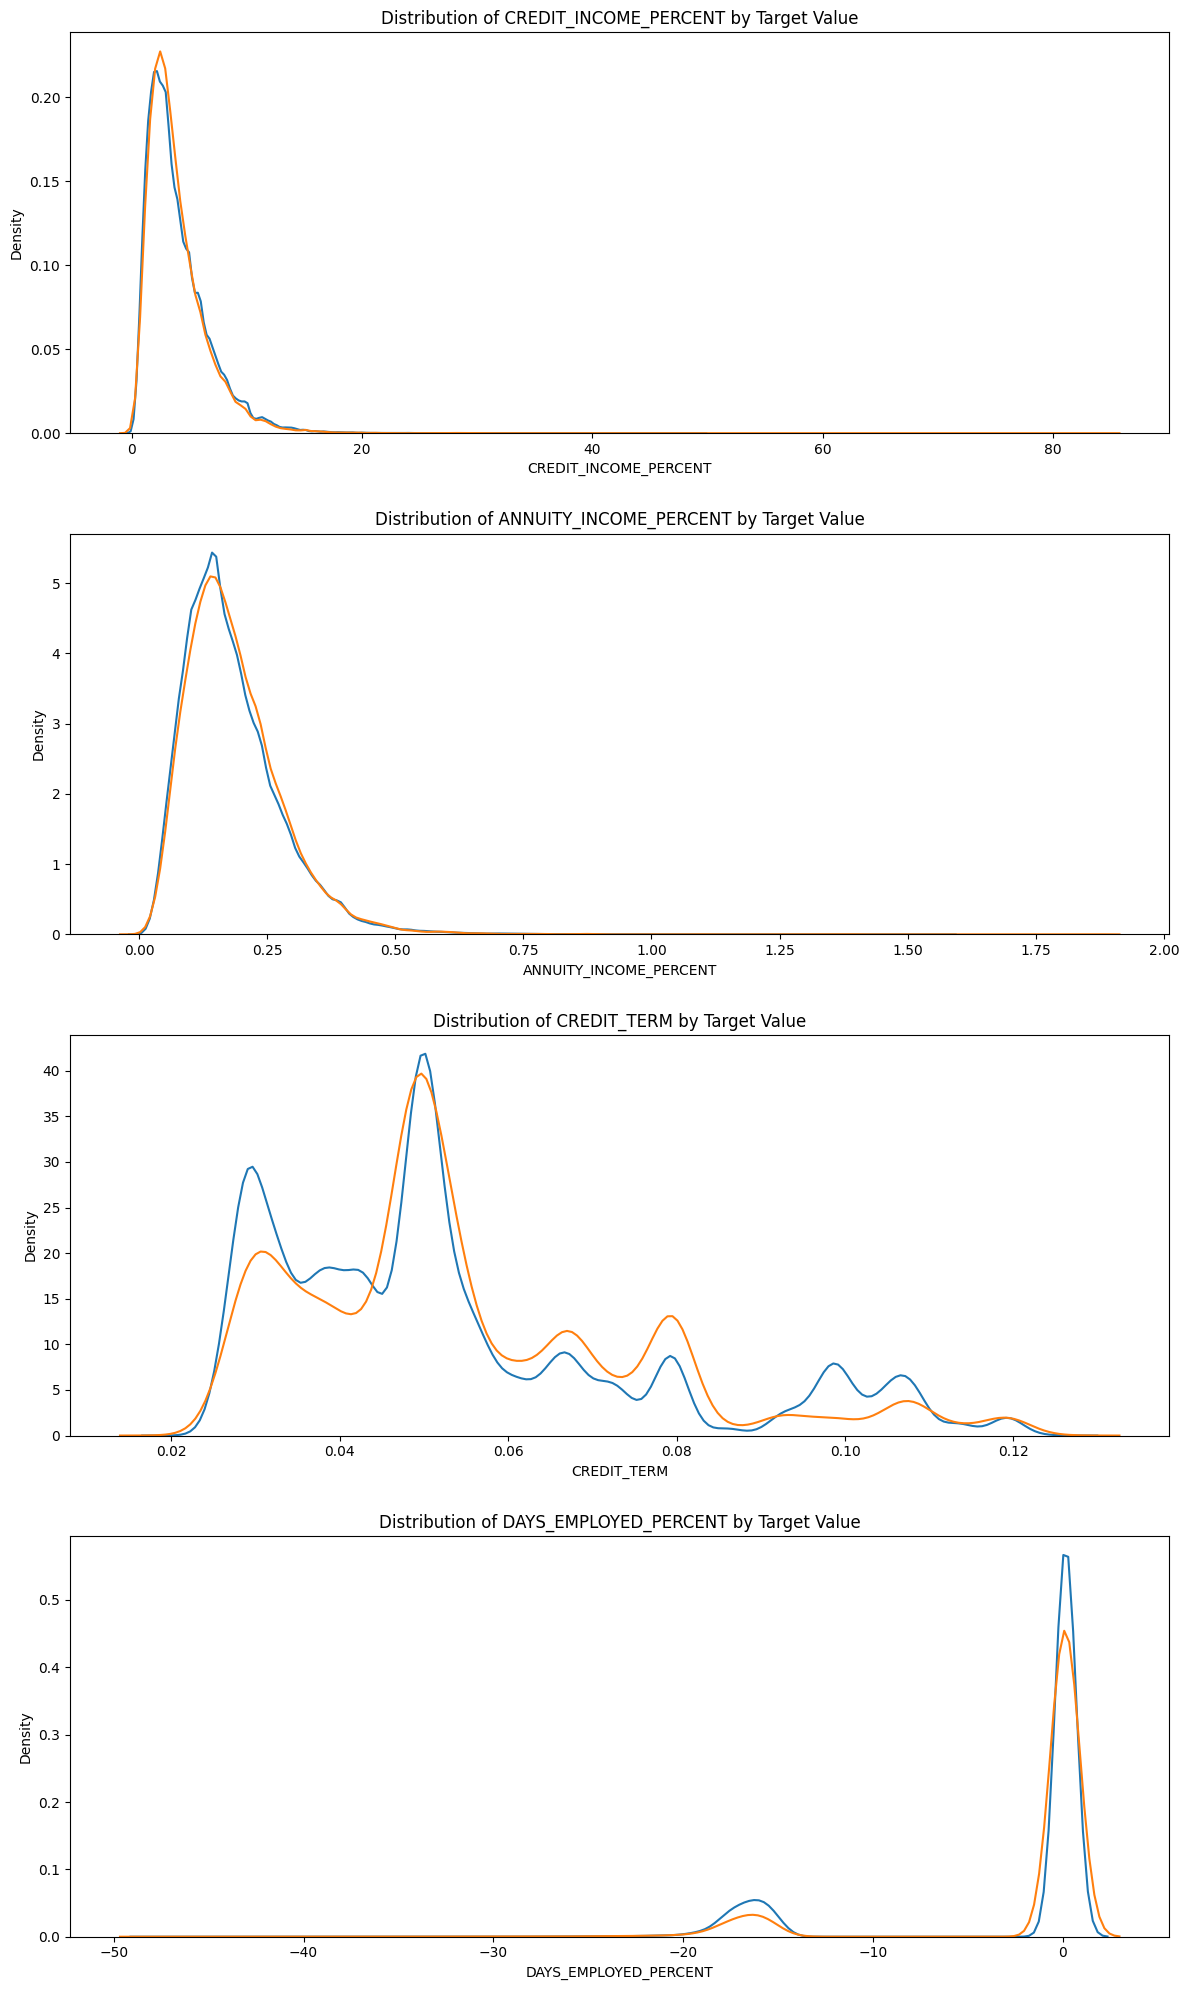

In [8]:
plt.figure(figsize = (12, 20))
# iterate through the new features
for i, feature in enumerate(['CREDIT_INCOME_PERCENT', 'ANNUITY_INCOME_PERCENT', 'CREDIT_TERM', 'DAYS_EMPLOYED_PERCENT']):
    
    # create a new subplot for each source
    plt.subplot(4, 1, i + 1)
    # plot repaid loans
    sns.kdeplot(app_train_domain.loc[app_train_domain['TARGET'] == 0, feature], label = 'target == 0')
    # plot loans that were not repaid
    sns.kdeplot(app_train_domain.loc[app_train_domain['TARGET'] == 1, feature], label = 'target == 1')
    
    # Label the plots
    plt.title('Distribution of %s by Target Value' % feature)
    plt.xlabel('%s' % feature); plt.ylabel('Density');
    
plt.tight_layout(h_pad = 2.5)

## Baseline 

Une baseline naïve consisterait à prédire 0.5 pour tous les clients (= incertitude totale), ce qui donne un AUC ROC de 0.5 — le score d'un modèle aléatoire. On sait déjà ce score, donc on passe directement à une baseline plus solide : la régression logistique.
On préprocesse d'abord les données en deux étapes :

Imputation : remplacement des valeurs manquantes par la médiane
Normalisation : mise à l'échelle des features (feature scaling)

In [9]:
# Drop the target from the training data
if 'TARGET' in app_train:
    train = app_train.drop(columns=['TARGET'])
else:
    train = app_train.copy()

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in train.columns:
    if train[col].dtype == 'object':
        train[col] = le.fit_transform(train[col].astype(str))

# Feature names
features = list(train.columns)

# Median imputation of missing values
imputer = SimpleImputer(strategy='median')  # ✅ SimpleImputer au lieu de Imputer

# Scale each feature to 0-1
scaler = MinMaxScaler(feature_range=(0, 1))

# Fit on the training data
imputer.fit(train)

# Transform both training and testing data
train = imputer.transform(train)

# Repeat with the scaler
scaler.fit(train)
train = scaler.transform(train)

print('Training data shape: ', train.shape)

Training data shape:  (307511, 121)


In [10]:
# ── Split train / validation ──────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

# Récupération de la target (depuis le CSV original qui contient TARGET)
labels = app_train['TARGET']

X_train, X_val, y_train, y_val = train_test_split(
    train, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels   # conserve la proportion de défauts (~8%)
)

print(f'X_train : {X_train.shape} | X_val : {X_val.shape}')
print(f'Défauts train : {y_train.mean()*100:.1f}%  |  Défauts val : {y_val.mean()*100:.1f}%')


X_train : (246008, 121) | X_val : (61503, 121)
Défauts train : 8.1%  |  Défauts val : 8.1%


## 🏷️ Fonction Coût Métier

> **Contexte métier** : un **Faux Négatif** (mauvais client prédit bon → crédit accordé → perte en capital) coûte **10×** plus qu'un **Faux Positif** (bon client rejeté → manque à gagner).  
> On optimise le **seuil de décision** pour minimiser ce coût asymétrique, plutôt que de rester naïvement à 0.5.


In [11]:
# ── Fonction coût métier ─────────────────────────────────────────────────────
# FN = mauvais client prédit bon  → crédit accordé → perte en capital  (coût = 10)
# FP = bon client prédit mauvais → crédit refusé  → manque à gagner    (coût = 1)

def cout_metier(y_true, y_proba, seuil=0.5, cout_fn=10, cout_fp=1):
    """Calcule le coût métier normalisé pour un seuil donné."""
    y_pred = (y_proba >= seuil).astype(int)
    fn = ((y_pred == 0) & (y_true == 1)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    return (cout_fn * fn + cout_fp * fp) / len(y_true)


def optimiser_seuil(y_true, y_proba, cout_fn=10, cout_fp=1, nb_seuils=100):
    """Retourne le seuil optimal et un DataFrame coût/seuil."""
    import pandas as pd
    seuils = np.linspace(0.01, 0.99, nb_seuils)
    rows = []
    for s in seuils:
        y_pred = (y_proba >= s).astype(int)
        fn = ((y_pred == 0) & (y_true == 1)).sum()
        fp = ((y_pred == 1) & (y_true == 0)).sum()
        rows.append({'seuil': s,
                     'cout_metier': (cout_fn * fn + cout_fp * fp) / len(y_true),
                     'fn': fn, 'fp': fp})
    df = pd.DataFrame(rows)
    seuil_opt = df.loc[df['cout_metier'].idxmin(), 'seuil']
    return seuil_opt, df


def plot_cout_vs_seuil(df_res, label='Modèle', ax=None):
    """Trace la courbe coût métier vs seuil sur un axe donné."""
    seuil_opt = df_res.loc[df_res['cout_metier'].idxmin(), 'seuil']
    cout_opt  = df_res['cout_metier'].min()
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 4))
    ax.plot(df_res['seuil'], df_res['cout_metier'], label=label)
    ax.axvline(x=seuil_opt, color='red', linestyle='--', alpha=0.7,
               label=f'Seuil opt = {seuil_opt:.2f} (coût={cout_opt:.3f})')
    ax.scatter([seuil_opt], [cout_opt], color='red', zorder=5)
    ax.set_xlabel('Seuil de décision')
    ax.set_ylabel('Coût métier normalisé')
    ax.set_title(f'Coût métier vs Seuil — {label}')
    ax.legend()
    return ax

print('✅ Fonctions coût métier définies (FN=10×FP)')


✅ Fonctions coût métier définies (FN=10×FP)


## Les modèles

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score
import mlflow, warnings
warnings.filterwarnings('ignore')

mlflow.sklearn.autolog(disable=True)   # on gère manuellement le logging
mlflow.xgboost.autolog(disable=True)

# ── Définition des modèles ────────────────────────────────────────────────────
MODELES = {
    'LogisticRegression': LogisticRegression(
        C=0.0001,
        class_weight='balanced',
        random_state=42,
        max_iter=1000
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=6,
        scale_pos_weight=12,   # équivalent class_weight='balanced'
        random_state=42,
        eval_metric='auc',
        verbosity=0
    ),
}


## Validation croisée méthode stratifiedkFold

In [13]:
# ── Validation croisée ── StratifiedKFold 5 folds ──────────────────────────
from sklearn.model_selection import StratifiedKFold, cross_val_score

print("=" * 60)
print("VALIDATION CROISÉE — StratifiedKFold (3 folds)")
print("=" * 60)

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
resultats_cv = {}

for nom, modele in MODELES.items():
    scores = cross_val_score(
        modele, X_train, y_train,
        cv=skf,
        scoring='roc_auc',
        n_jobs=-1
    )
    resultats_cv[nom] = {     
        'scores': scores,
        'mean': scores.mean(),
        'std': scores.std()
    }
    print(f"\n{nom}")
    print(f"  AUC par fold : {[round(s, 4) for s in scores]}")
    print(f"  Moyenne      : {scores.mean():.4f}")
    print(f"  Écart-type   : {scores.std():.4f}")

print("\n" + "=" * 60)

VALIDATION CROISÉE — StratifiedKFold (3 folds)

LogisticRegression
  AUC par fold : [np.float64(0.7019), np.float64(0.7029), np.float64(0.7002)]
  Moyenne      : 0.7017
  Écart-type   : 0.0011

RandomForest
  AUC par fold : [np.float64(0.7169), np.float64(0.7183), np.float64(0.7187)]
  Moyenne      : 0.7180
  Écart-type   : 0.0008

XGBoost
  AUC par fold : [np.float64(0.7484), np.float64(0.7507), np.float64(0.7466)]
  Moyenne      : 0.7486
  Écart-type   : 0.0017



---

**Interprétation**

**Classement** : XGBoost > Random Forest > Logistic Regression, avec un écart 
significatif entre XGBoost (0.74) et les deux autres modèles (0.71 et 0.70).

**Stabilité** : Les trois modèles présentent des écarts-types très faibles (< 0.002), 
ce qui indique un modèle fiable sur les différents découpages des données. 
Aucun modèle ne souffre de sur-apprentissage sur un fold particulier.

**Choix du modèle champion** : XGBoost est retenu comme modèle principal pour la 
suite (optimisation des hyperparamètres, ajustement du seuil métier), en raison de 
sa meilleure AUC et de sa stabilité.

---

## 🔁 Pipeline — Comparaison des modèles

On entraîne les 3 modèles dans une **boucle unifiée** :  
- Tracking MLflow (AUC + coût métier loggés)  
- Courbe coût métier vs seuil  
- Tableau récapitulatif final



🔄 Entraînement : LogisticRegression


2026/03/19 09:50:14 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/19 09:50:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/19 09:50:28 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


cout@0.5=0.5930 | cout_opt=0.5894 | seuil_opt=0.51

🔄 Entraînement : RandomForest


2026/03/19 09:50:41 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/19 09:51:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/19 09:51:42 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


cout@0.5=0.8055 | cout_opt=0.5651 | seuil_opt=0.09

🔄 Entraînement : XGBoost


2026/03/19 09:52:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/19 09:52:33 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


cout@0.5=0.5374 | cout_opt=0.5337 | seuil_opt=0.52


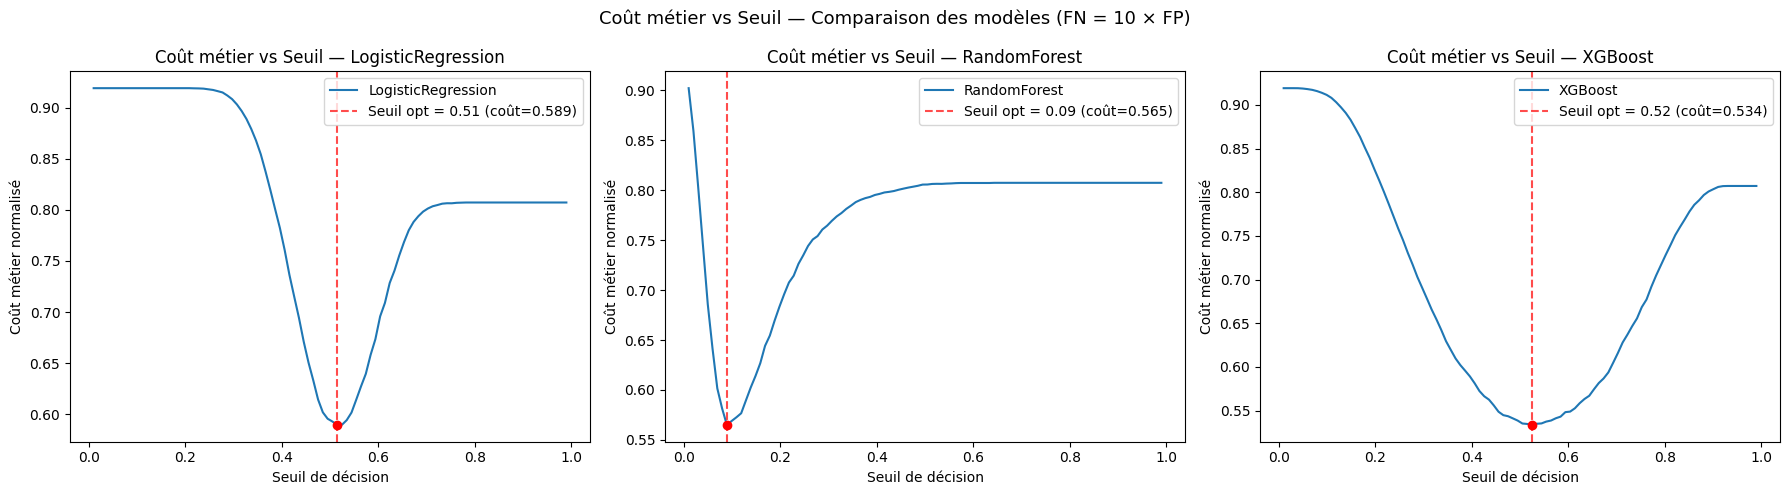

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score
import mlflow, warnings
warnings.filterwarnings('ignore')

# ── Pipeline d'entraînement + évaluation ─────────────────────────────────────
mlflow.sklearn.autolog(log_models=True)
mlflow.xgboost.autolog(log_models=True)

resultats = {}
probas     = {}
fig, axes  = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Coût métier vs Seuil — Comparaison des modèles (FN = 10 × FP)', fontsize=13)

for ax, (nom, modele) in zip(axes, MODELES.items()):
    print(f'\n🔄 Entraînement : {nom}')

    with mlflow.start_run(run_name=nom):
         # ── Tags
        mlflow.set_tag('modele',   nom)
        mlflow.set_tag('etape',    'baseline_comparaison')
        mlflow.set_tag('dataset',  'application_train')

        # Entraînement
        modele.fit(X_train, y_train)
        y_proba = modele.predict_proba(X_val)[:, 1]
        probas[nom] = y_proba

        # ── Coût métier : seuil 0.5 vs seuil optimal
        cout_05       = cout_metier(y_val, y_proba, seuil=0.5)
        seuil_opt, df_couts = optimiser_seuil(y_val, y_proba)
        cout_opt      = df_couts['cout_metier'].min()
        best_row      = df_couts.loc[df_couts['cout_metier'].idxmin()]

        # ── MLflow logging
        mlflow.log_metric('cout_seuil_05',      cout_05)
        mlflow.log_metric('cout_seuil_optimal', cout_opt)
        mlflow.log_metric('fn_seuil_optimal',   int(best_row['fn']))
        mlflow.log_metric('fp_seuil_optimal',   int(best_row['fp']))
        mlflow.log_metric('cv_auc_mean', resultats_cv[nom]['mean'])
        mlflow.log_metric('cv_auc_std',  resultats_cv[nom]['std'])
        mlflow.log_param ('seuil_optimal',      round(seuil_opt, 3))

        # ── Courbe coût vs seuil
        plot_cout_vs_seuil(df_couts, label=nom, ax=ax)

        # ── Stockage résultats
        resultats[nom] = {
            'Coût @seuil=0.5': round(cout_05, 4),
            'Coût @seuil_opt': round(cout_opt, 4),
            'Seuil optimal':   round(seuil_opt, 3),
        }
        print(
            f'cout@0.5={cout_05:.4f} | cout_opt={cout_opt:.4f} | '
            f'seuil_opt={seuil_opt:.2f}'
        )
        
plt.tight_layout()
plt.show()


## 📊 Tableau récapitulatif — Métriques techniques & métier

In [15]:
import pandas as pd

df_recap = pd.DataFrame(resultats).T
df_recap.index.name = 'Modèle'
print(df_recap.to_string())

# Meilleur modèle selon le coût métier optimal
best = df_recap['Coût @seuil_opt'].idxmin()
print(f'\n🏆 Meilleur modèle (coût métier) : {best}')
print(f'   → Coût = {df_recap.loc[best, "Coût @seuil_opt"]} | Seuil = {df_recap.loc[best, "Seuil optimal"]}')


                    Coût @seuil=0.5  Coût @seuil_opt  Seuil optimal
Modèle                                                             
LogisticRegression           0.5930           0.5894          0.515
RandomForest                 0.8055           0.5651          0.089
XGBoost                      0.5374           0.5337          0.525

🏆 Meilleur modèle (coût métier) : XGBoost
   → Coût = 0.5337 | Seuil = 0.525


## 🔍 Feature Importance — XGBoost (modèle champion)

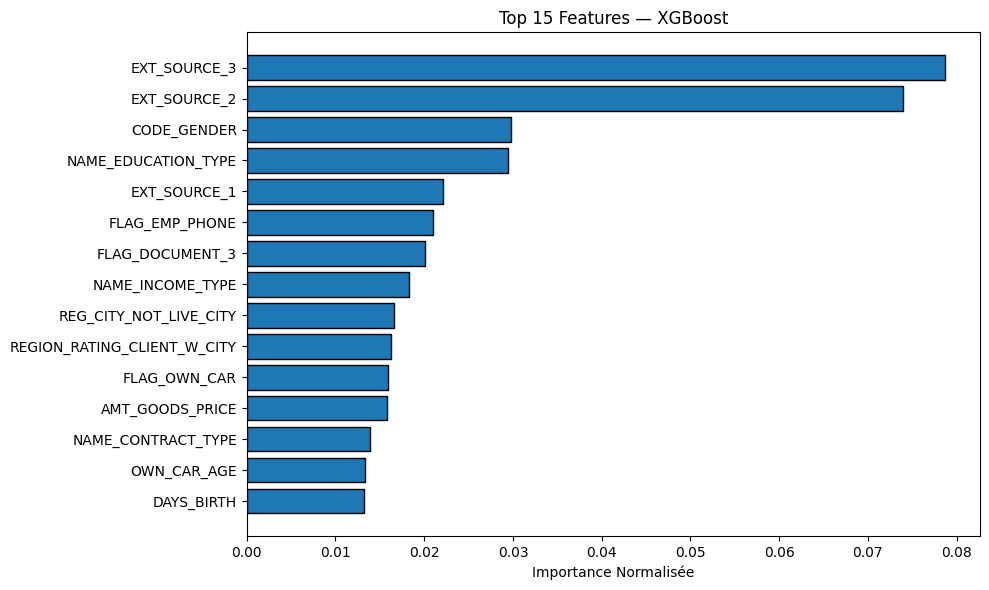

                    feature  importance  importance_norm
               EXT_SOURCE_3    0.078694         0.078694
               EXT_SOURCE_2    0.073917         0.073917
                CODE_GENDER    0.029817         0.029817
        NAME_EDUCATION_TYPE    0.029387         0.029387
               EXT_SOURCE_1    0.022088         0.022088
             FLAG_EMP_PHONE    0.021041         0.021041
            FLAG_DOCUMENT_3    0.020086         0.020086
           NAME_INCOME_TYPE    0.018309         0.018309
     REG_CITY_NOT_LIVE_CITY    0.016628         0.016628
REGION_RATING_CLIENT_W_CITY    0.016251         0.016251


In [16]:
def plot_feature_importances(model, feature_names, top_n=15):
    """Affiche les feature importances normalisées d'un modèle arbre."""
    importances = model.feature_importances_
    df_fi = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).reset_index(drop=True)
    df_fi['importance_norm'] = df_fi['importance'] / df_fi['importance'].sum()

    plt.figure(figsize=(10, 6))
    ax = plt.subplot()
    idx = list(reversed(list(range(top_n))))
    ax.barh(idx, df_fi['importance_norm'].head(top_n), align='center', edgecolor='k')
    ax.set_yticks(idx)
    ax.set_yticklabels(df_fi['feature'].head(top_n))
    plt.xlabel('Importance Normalisée')
    plt.title(f'Top {top_n} Features — XGBoost')
    plt.tight_layout()
    plt.show()
    return df_fi

fi_xgb = plot_feature_importances(MODELES['XGBoost'], features, top_n=15)
print(fi_xgb.head(10).to_string(index=False))


---
## ✅ Checklist — Étape 1

| Indicateur | Statut |
|---|---|
| Exploration données brutes | ✅ |
| Fusion train + test cohérente | ✅ |
| Suppression colonnes >40% NaN | ✅ |
| Correction anomalie DAYS_EMPLOYED | ✅ |
| Encodage variables catégorielles | ✅ |
| Nouvelles features métier | ✅ |
| Remplacement valeurs infinies | ✅ |
| Datasets sauvegardés en parquet | ✅ |

In [17]:
@mlflow.trace
def foo(a):
    return a + bar(a)

# Various attributes can be passed to the decorator
# to modify the information contained in the span
@mlflow.trace(name = "custom_name", attributes = { "key": "value" })
def bar(b):
    return b + 1

# Invoking the traced function will cause a trace to be logged
foo(1)

3